# 0.0 Imports

In [39]:
pip install catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.5.2-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.17.0-py3-none-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 31.9 MB/s  0:00:006.9 MB/s eta 0:00:01:01
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.5.2-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.17.0-py3-none-any.whl (444 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]━━ 3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


In [40]:
import os
os.getcwd()
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import polars as pl

In [41]:
# Definir nomes das colunas (Criteo não tem header)
cols = (["label"]
        + [f"I{i}" for i in range(1,14)]
        + [f"C{i}" for i in range(1,27)])

df = pl.read_csv(
    "data/sample/train_2M.txt",
    separator="\t",
    has_header=False,
    new_columns=cols,
    null_values=["", "NA"]
)

df.shape

(2000000, 40)

In [14]:
df.head()

label,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
0,1,1,5,0,1382,4,15,2,181,1,2,null,2,"""68fd1e64""","""80e26c9b""","""fb936136""","""7b4723c4""","""25c83c98""","""7e0ccccf""","""de7995b8""","""1f89b562""","""a73ee510""","""a8cd5504""","""b2cb9c98""","""37c9c164""","""2824a5f6""","""1adce6ef""","""8ba8b39a""","""891b62e7""","""e5ba7672""","""f54016b9""","""21ddcdc9""","""b1252a9d""","""07b5194c""",null,"""3a171ecb""","""c5c50484""","""e8b83407""","""9727dd16"""
0,2,0,44,1,102,8,2,2,4,1,1,null,4,"""68fd1e64""","""f0cf0024""","""6f67f7e5""","""41274cd7""","""25c83c98""","""fe6b92e5""","""922afcc0""","""0b153874""","""a73ee510""","""2b53e5fb""","""4f1b46f3""","""623049e6""","""d7020589""","""b28479f6""","""e6c5b5cd""","""c92f3b61""","""07c540c4""","""b04e4670""","""21ddcdc9""","""5840adea""","""60f6221e""",null,"""3a171ecb""","""43f13e8b""","""e8b83407""","""731c3655"""
0,2,0,1,14,767,89,4,2,245,1,3,3,45,"""287e684f""","""0a519c5c""","""02cf9876""","""c18be181""","""25c83c98""","""7e0ccccf""","""c78204a1""","""0b153874""","""a73ee510""","""3b08e48b""","""5f5e6091""","""8fe001f4""","""aa655a2f""","""07d13a8f""","""6dc710ed""","""36103458""","""8efede7f""","""3412118d""",null,null,"""e587c466""","""ad3062eb""","""3a171ecb""","""3b183c5c""",null,null
0,null,893,null,null,4392,null,0,0,0,null,0,null,null,"""68fd1e64""","""2c16a946""","""a9a87e68""","""2e17d6f6""","""25c83c98""","""fe6b92e5""","""2e8a689b""","""0b153874""","""a73ee510""","""efea433b""","""e51ddf94""","""a30567ca""","""3516f6e6""","""07d13a8f""","""18231224""","""52b8680f""","""1e88c74f""","""74ef3502""",null,null,"""6b3a5ca6""",null,"""3a171ecb""","""9117a34a""",null,null
0,3,-1,null,0,2,0,3,0,0,1,1,null,0,"""8cf07265""","""ae46a29d""","""c81688bb""","""f922efad""","""25c83c98""","""13718bbd""","""ad9fa255""","""0b153874""","""a73ee510""","""5282c137""","""e5d8af57""","""66a76a26""","""f06c53ac""","""1adce6ef""","""8ff4b403""","""01adbab4""","""1e88c74f""","""26b3c7a7""",null,null,"""21c9516a""",null,"""32c7478e""","""b34f3128""",null,null


# 1.0 Data Describe

In [15]:
df.group_by("label").len().with_columns(
    (pl.col("len") / pl.col("len").sum()).alias("proportion")
)

label,len,proportion
i64,u32,f64
0,1496870,0.748435
1,503130,0.251565


In [16]:
# valores ausentes variaveis numericas
df.select([
    pl.col(f"I{i}").null_count().alias(f"I{i}_nulls")
    for i in range(1,14)
])

I1_nulls,I2_nulls,I3_nulls,I4_nulls,I5_nulls,I6_nulls,I7_nulls,I8_nulls,I9_nulls,I10_nulls,I11_nulls,I12_nulls,I13_nulls
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
849735,0,454348,473222,45417,437836,79899,1197,79899,849735,79899,1542352,473222


In [17]:
# cardinalidade categoricas
df.select([
    pl.col(f"C{i}").n_unique().alias(f"C{i}_unique")
    for i in range(1,27)
])

C1_unique,C2_unique,C3_unique,C4_unique,C5_unique,C6_unique,C7_unique,C8_unique,C9_unique,C10_unique,C11_unique,C12_unique,C13_unique,C14_unique,C15_unique,C16_unique,C17_unique,C18_unique,C19_unique,C20_unique,C21_unique,C22_unique,C23_unique,C24_unique,C25_unique,C26_unique
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1370,541,597026,200785,284,17,11387,600,3,39666,4953,498707,3097,26,10159,371933,10,4256,1957,4,443312,17,15,59876,81,43274


In [18]:
# Média das numéricas por label
df.group_by("label").agg(
    [pl.col(f"I{i}").mean().alias(f"I{i}_mean") for i in range(1,14)]
)

label,I1_mean,I2_mean,I3_mean,I4_mean,I5_mean,I6_mean,I7_mean,I8_mean,I9_mean,I10_mean,I11_mean,I12_mean,I13_mean
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,2.690648,94.250682,21.761693,7.214772,22086.12993,134.429536,11.175457,13.484675,99.790422,0.520007,1.98013,0.720535,8.366957
1,4.598039,128.416366,16.178569,6.114439,9084.411012,61.754298,23.037188,12.19372,108.908386,0.786781,3.765054,1.953059,5.457081


In [19]:
df_bucket = (
    df.with_columns(
        pl.when(pl.col("I2").is_null())
          .then(pl.lit("null"))
          .when(pl.col("I2") == 0)
          .then(pl.lit("zero"))
          .when(pl.col("I2") < 10)
          .then(pl.lit("baixo"))
          .when(pl.col("I2") < 100)
          .then(pl.lit("medio"))
          .otherwise(pl.lit("alto"))
          .alias("I2_bucket")
    )
    .group_by("I2_bucket")
    .agg([
        pl.mean("label").alias("ctr"),
        pl.len().alias("volume")
    ])
    .sort("volume", descending=True)
)

df_bucket

I2_bucket,ctr,volume
str,f64,u32
"""baixo""",0.2487,891545
"""medio""",0.24569,469355
"""zero""",0.236107,346347
"""alto""",0.287997,292753


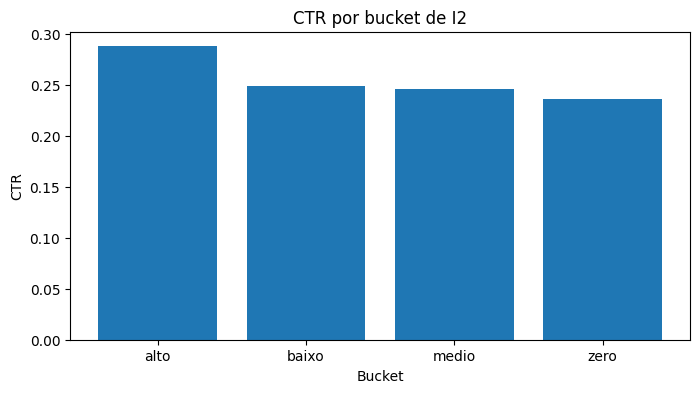

In [20]:
import matplotlib.pyplot as plt

b = df_bucket.to_pandas().sort_values("I2_bucket")  # ordenação simples
plt.figure(figsize=(8,4))
plt.bar(b["I2_bucket"], b["ctr"])
plt.title("CTR por bucket de I2")
plt.xlabel("Bucket")
plt.ylabel("CTR")
plt.show()

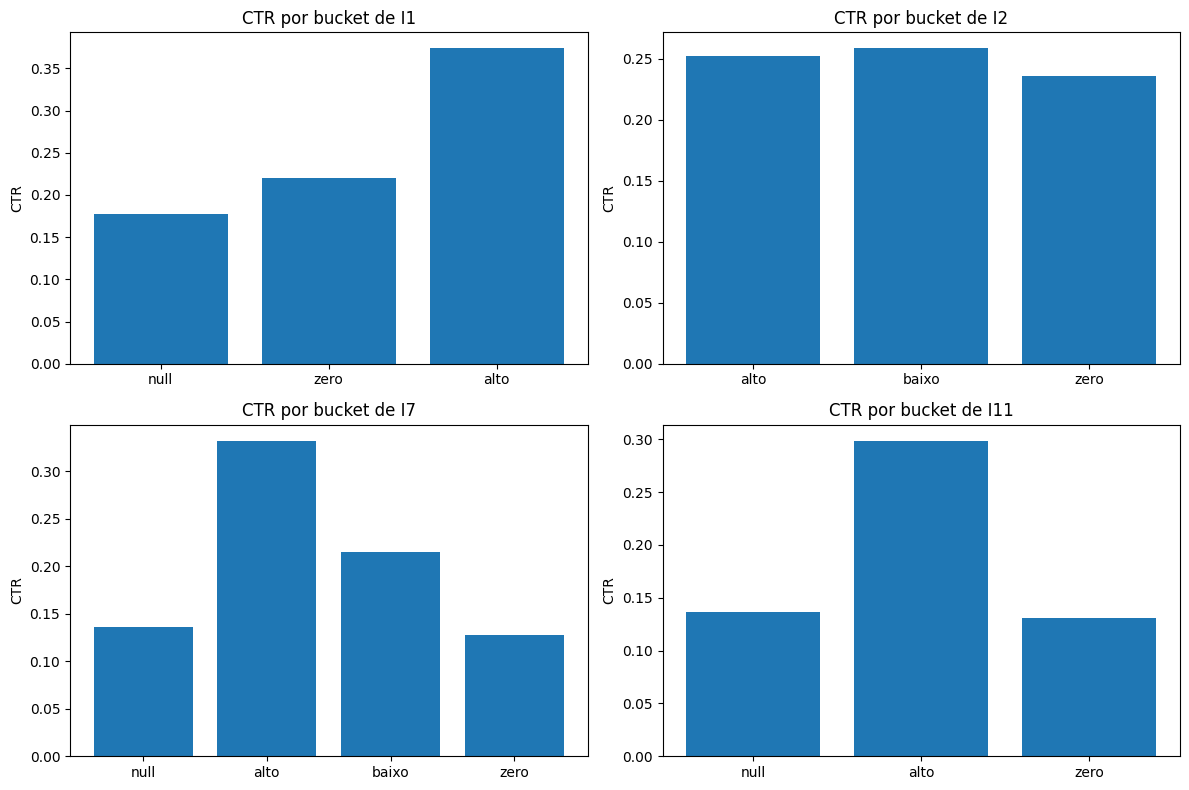

In [21]:
import polars as pl
import matplotlib.pyplot as plt

variaveis = ["I1", "I2", "I7", "I11"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, var in enumerate(variaveis):
    
    # calcular mediana
    mediana = df.select(pl.col(var).median()).item()
    
    df_bucket = (
        df.with_columns(
            pl.when(pl.col(var).is_null())
              .then(pl.lit("null"))
              .when(pl.col(var) == 0)
              .then(pl.lit("zero"))
              .when(pl.col(var) < mediana)
              .then(pl.lit("baixo"))
              .otherwise(pl.lit("alto"))
              .alias("bucket")
        )
        .group_by("bucket")
        .agg([
            pl.mean("label").alias("ctr"),
            pl.len().alias("volume")
        ])
    )
    
    bucket_pd = df_bucket.to_pandas()
    
    axes[idx].bar(bucket_pd["bucket"], bucket_pd["ctr"])
    axes[idx].set_title(f"CTR por bucket de {var}")
    axes[idx].set_ylabel("CTR")

plt.tight_layout()
plt.show()

In [22]:
## Categoricas C9
df.group_by("C9").agg([
    pl.mean("label").alias("ctr"),
    pl.len().alias("volume")
]).sort("ctr", descending=True)

C9,ctr,volume
str,f64,u32
"""a73ee510""",0.265838,1799023
"""7cc72ec2""",0.123827,200643
"""a18233ea""",0.110778,334


In [23]:
## Categoricas C14
df.group_by("C14").agg([
    pl.mean("label").alias("ctr"),
    pl.len().alias("volume")
]).sort("ctr", descending=True)

C14,ctr,volume
str,f64,u32
"""ab7390e9""",0.634635,999
"""32813e21""",0.465617,11939
"""95a6ab8c""",0.417391,115
"""dcd762ee""",0.38661,3047
"""64c94865""",0.376398,98457
…,…,…
"""0bc7c8c2""",0.118421,380
"""5aebfb83""",0.113391,926
"""8ceecbc8""",0.064951,30346


## Validando correlacao entre variaveis categoricas e numericas
Observa-se que impressões associadas a alto histórico (I1 elevado) e contexto favorável (C9 forte) apresentam CTR de 37%, enquanto o grupo com baixo histórico e contexto fraco apresenta apenas 12%. Isso indica forte concentração da performance em segmentos específicos, sugerindo alto potencial de otimização via priorização de inventário.

In [24]:
# Definir C9 forte (ajuste se quiser usar outra)
c9_forte = "a73ee510"

# Mediana de I1
mediana_i1 = df.select(pl.col("I1").median()).item()

df_combo = (
    df.with_columns([
        pl.when(pl.col("I1") >= mediana_i1)
          .then(pl.lit("alto"))
          .otherwise(pl.lit("baixo"))
          .alias("I1_bucket"),
        
        pl.when(pl.col("C9") == c9_forte)
          .then(pl.lit("forte"))
          .otherwise(pl.lit("fraco"))
          .alias("C9_bucket")
    ])
    .with_columns(
        (pl.col("I1_bucket") + "_" + pl.col("C9_bucket")).alias("grupo")
    )
    .group_by("grupo")
    .agg([
        pl.mean("label").alias("ctr"),
        pl.len().alias("volume")
    ])
    .sort("ctr", descending=True)
)

df_combo

grupo,ctr,volume
str,f64,u32
"""alto_forte""",0.374008,642622
"""alto_fraco""",0.336842,190
"""baixo_forte""",0.205726,1156401
"""baixo_fraco""",0.123604,200787


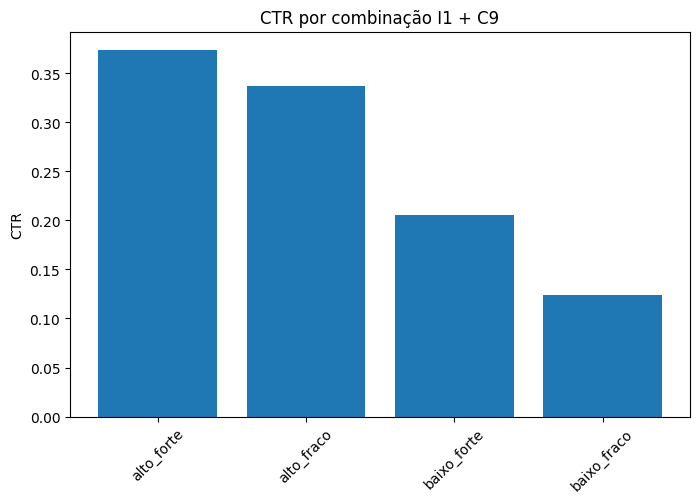

In [25]:
import matplotlib.pyplot as plt

combo_pd = df_combo.to_pandas()

plt.figure(figsize=(8,5))
plt.bar(combo_pd["grupo"], combo_pd["ctr"])
plt.title("CTR por combinação I1 + C9")
plt.ylabel("CTR")
plt.xticks(rotation=45)
plt.show()

In [26]:
c9_forte = "a73ee510"
mediana_i1 = df.select(pl.col("I1").median()).item()

df_tag = df.with_columns([
    pl.when(pl.col("I1") >= mediana_i1).then(pl.lit("alto")).otherwise(pl.lit("baixo")).alias("I1_bucket"),
    pl.when(pl.col("C9") == c9_forte).then(pl.lit("forte")).otherwise(pl.lit("fraco")).alias("C9_bucket"),
]).with_columns(
    (pl.col("I1_bucket") + "_" + pl.col("C9_bucket")).alias("grupo")
)

In [27]:
res = (
    df_tag.group_by("grupo")
    .agg([
        pl.sum("label").alias("cliques"),
        pl.len().alias("volume"),
        pl.mean("label").alias("ctr"),
    ])
)

res

grupo,cliques,volume,ctr
str,i64,u32,f64
"""baixo_forte""",237902,1156401,0.205726
"""baixo_fraco""",24818,200787,0.123604
"""alto_fraco""",64,190,0.336842
"""alto_forte""",240346,642622,0.374008


In [28]:
totais = df_tag.select([
    pl.sum("label").alias("cliques_total"),
    pl.len().alias("volume_total")
]).row(0)

cliques_total = totais[0]
volume_total = totais[1]

res_share = res.with_columns([
    (pl.col("volume") / volume_total).alias("share_volume"),
    (pl.col("cliques") / cliques_total).alias("share_cliques"),
]).sort("share_cliques", descending=True)

res_share

grupo,cliques,volume,ctr,share_volume,share_cliques
str,i64,u32,f64,f64,f64
"""alto_forte""",240346,642622,0.374008,0.321311,0.477702
"""baixo_forte""",237902,1156401,0.205726,0.5782005,0.472844
"""baixo_fraco""",24818,200787,0.123604,0.1003935,0.049327
"""alto_fraco""",64,190,0.336842,0.000095,0.000127


In [29]:
ctr_global = df.select(pl.mean("label")).item()
ctr_global

0.251565

In [30]:
res_share = res_share.with_columns(
    (pl.col("ctr") / ctr_global).alias("lift_vs_media")
)
res_share

grupo,cliques,volume,ctr,share_volume,share_cliques,lift_vs_media
str,i64,u32,f64,f64,f64,f64
"""alto_forte""",240346,642622,0.374008,0.321311,0.477702,1.486727
"""baixo_forte""",237902,1156401,0.205726,0.5782005,0.472844,0.817786
"""baixo_fraco""",24818,200787,0.123604,0.1003935,0.049327,0.491339
"""alto_fraco""",64,190,0.336842,0.000095,0.000127,1.338986


In [31]:
res_ord = res_share.sort("ctr", descending=True).with_columns([
    pl.col("share_cliques").cum_sum().alias("cum_share_cliques"),
    pl.col("share_volume").cum_sum().alias("cum_share_volume"),
])

res_ord

grupo,cliques,volume,ctr,share_volume,share_cliques,lift_vs_media,cum_share_cliques,cum_share_volume
str,i64,u32,f64,f64,f64,f64,f64,f64
"""alto_forte""",240346,642622,0.374008,0.321311,0.477702,1.486727,0.477702,0.321311
"""alto_fraco""",64,190,0.336842,0.000095,0.000127,1.338986,0.477829,0.321406
"""baixo_forte""",237902,1156401,0.205726,0.5782005,0.472844,0.817786,0.950673,0.8996065
"""baixo_fraco""",24818,200787,0.123604,0.1003935,0.049327,0.491339,1.0,1.0


In [32]:
low_card = ["C6","C9","C14","C20","C22","C23"]

for col in low_card:
    print(f"\n==== {col} ====")
    print(
        df.group_by(col)
          .agg([
              pl.mean("label").alias("ctr"),
              pl.len().alias("volume")
          ])
          .sort("ctr", descending=True)
    )


==== C6 ====
shape: (17, 3)
┌──────────┬──────────┬────────┐
│ C6       ┆ ctr      ┆ volume │
│ ---      ┆ ---      ┆ ---    │
│ str      ┆ f64      ┆ u32    │
╞══════════╪══════════╪════════╡
│ ef5a8cc6 ┆ 0.5      ┆ 2      │
│ 6f6d9be8 ┆ 0.325075 ┆ 45568  │
│ f1f2de2d ┆ 0.292683 ┆ 82     │
│ 3bf701e7 ┆ 0.271462 ┆ 39232  │
│ fe6b92e5 ┆ 0.269691 ┆ 457026 │
│ …        ┆ …        ┆ …      │
│ 3c46edb2 ┆ 0.181818 ┆ 11     │
│ fdf16bc4 ┆ 0.129032 ┆ 31     │
│ 3bc1ed4d ┆ 0.0      ┆ 2      │
│ 825a7058 ┆ 0.0      ┆ 1      │
│ 051f8ea4 ┆ 0.0      ┆ 2      │
└──────────┴──────────┴────────┘

==== C9 ====
shape: (3, 3)
┌──────────┬──────────┬─────────┐
│ C9       ┆ ctr      ┆ volume  │
│ ---      ┆ ---      ┆ ---     │
│ str      ┆ f64      ┆ u32     │
╞══════════╪══════════╪═════════╡
│ a73ee510 ┆ 0.265838 ┆ 1799023 │
│ 7cc72ec2 ┆ 0.123827 ┆ 200643  │
│ a18233ea ┆ 0.110778 ┆ 334     │
└──────────┴──────────┴─────────┘

==== C14 ====
shape: (26, 3)
┌──────────┬──────────┬────────┐
│ C14      ┆ 

# Modelling

In [33]:
#feature selection
features_num = ["I1","I2","I7","I11"]
features_cat = ["C9","C14"]

cols_model = features_num + features_cat + ["label"]

df_model = df.select(cols_model)

In [34]:
# 1) Ler sample
cols = (["label"] + [f"I{i}" for i in range(1,14)] + [f"C{i}" for i in range(1,27)])
df = pl.read_csv(
    "data/sample/train_2M.txt",
    separator="\t",
    has_header=False,
    new_columns=cols,
    null_values=["", "NA"]
)

# 2) Features V1
features_num = ["I1","I2","I7","I11"]
features_cat = ["C9","C14"]
cols_model = features_num + features_cat + ["label"]

df_model = df.select(cols_model)

# 3) Converter para pandas (compatível com sklearn)
df_model_pd = df_model.to_pandas()
X = df_model_pd.drop(columns=["label"])
y = df_model_pd["label"]

# garantir tipo texto nas categóricas
for c in features_cat:
    X[c] = X[c].astype(str)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape, y_train.mean(), y_test.mean())

(1600000, 6) (400000, 6) 0.251565 0.251565


/Users/hugomes/projects/criteo/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC-AUC (test): 0.6674
CTR global (test): 0.2516
CTR top 20% (test): 0.4283
Lift@20%: 1.702


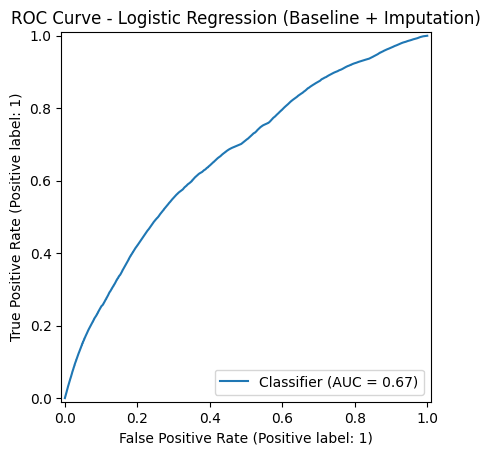

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd

features_num = ["I1","I2","I7","I11"]
features_cat = ["C9","C14"]

# Pipelines por tipo
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # ou constant="MISSING"
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, features_num),
        ("cat", cat_pipe, features_cat),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)

probs_test = clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probs_test)
print(f"ROC-AUC (test): {auc:.4f}")

df_eval = pd.DataFrame({"y": y_test.values, "score": probs_test}).sort_values("score", ascending=False)
top_k = int(len(df_eval) * 0.2)

ctr_global = df_eval["y"].mean()
ctr_top20 = df_eval.head(top_k)["y"].mean()
lift20 = ctr_top20 / ctr_global

print(f"CTR global (test): {ctr_global:.4f}")
print(f"CTR top 20% (test): {ctr_top20:.4f}")
print(f"Lift@20%: {lift20:.3f}")

RocCurveDisplay.from_predictions(y_test, probs_test)
plt.title("ROC Curve - Logistic Regression (Baseline + Imputation)")
plt.show()

In [42]:
# CATBOOST ML
cat_features_idx = [X_train.columns.get_loc(c) for c in features_cat]

In [43]:
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    eval_metric="AUC",
    verbose=100,
    random_seed=42
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.6631485	best: 0.6631485 (0)	total: 250ms	remaining: 1m 14s
100:	test: 0.6947613	best: 0.6947613 (100)	total: 16.6s	remaining: 32.7s
200:	test: 0.6955893	best: 0.6955893 (200)	total: 35.2s	remaining: 17.3s
299:	test: 0.6959029	best: 0.6959031 (297)	total: 54.2s	remaining: 0us

bestTest = 0.6959030931
bestIteration = 297

Shrink model to first 298 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.1, random_seed=42, verbose=100)

In [44]:
probs_cat = cat_model.predict_proba(X_test)[:, 1]

auc_cat = roc_auc_score(y_test, probs_cat)
print(f"CatBoost ROC-AUC: {auc_cat:.4f}")

CatBoost ROC-AUC: 0.6959


In [45]:
df_eval_cat = pd.DataFrame({
    "y": y_test,
    "score": probs_cat
}).sort_values("score", ascending=False)

top_k = int(len(df_eval_cat) * 0.2)

ctr_global = df_eval_cat["y"].mean()
ctr_top20 = df_eval_cat.head(top_k)["y"].mean()

lift20_cat = ctr_top20 / ctr_global

print(f"CTR top 20% (CatBoost): {ctr_top20:.4f}")
print(f"Lift@20% (CatBoost): {lift20_cat:.3f}")

CTR top 20% (CatBoost): 0.4636
Lift@20% (CatBoost): 1.843


In [46]:
# simulação simples
impressoes = 1_000_000

cliques_sem_modelo = impressoes * ctr_global
cliques_com_modelo = impressoes * ctr_top20

ganho_percentual = (cliques_com_modelo / cliques_sem_modelo) - 1

print(f"Ganho percentual estimado: {ganho_percentual:.2%}")

Ganho percentual estimado: 84.27%
